In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load model and data
model = joblib.load('../models/xgboost_model.joblib')
feature_names = joblib.load('../models/feature_names.joblib')

df = pd.read_csv('../data/insurance.csv')

# Prepare data (same as modeling)
df_model = df.copy()
df_model['sex'] = LabelEncoder().fit_transform(df_model['sex'])
df_model['smoker'] = LabelEncoder().fit_transform(df_model['smoker'])
df_model = pd.get_dummies(df_model, columns=['region'], drop_first=True)

X = df_model[feature_names]
y = np.log1p(df_model['charges'])

# SHAP explainer
explainer = shap.Explainer(model)
shap_values = explainer(X)

print("SHAP values computed!")
print(f"Data shape: {X.shape}")

C:\Users\jehay\Desktop\Capstone\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values computed!
Data shape: (1338, 8)


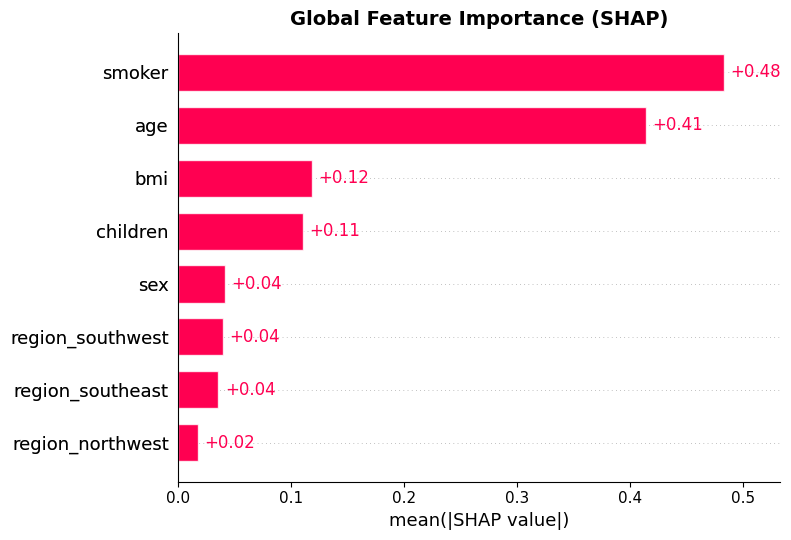

In [3]:

plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=8, show=False)
plt.title('Global Feature Importance (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

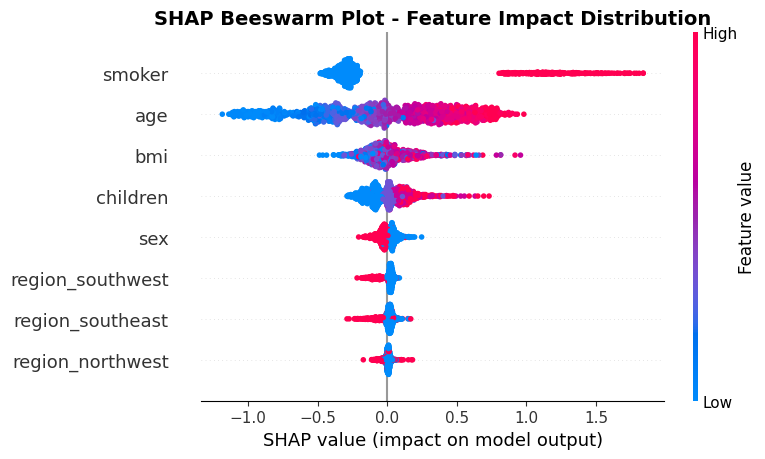

In [4]:

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=8, show=False)
plt.title('SHAP Beeswarm Plot - Feature Impact Distribution', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

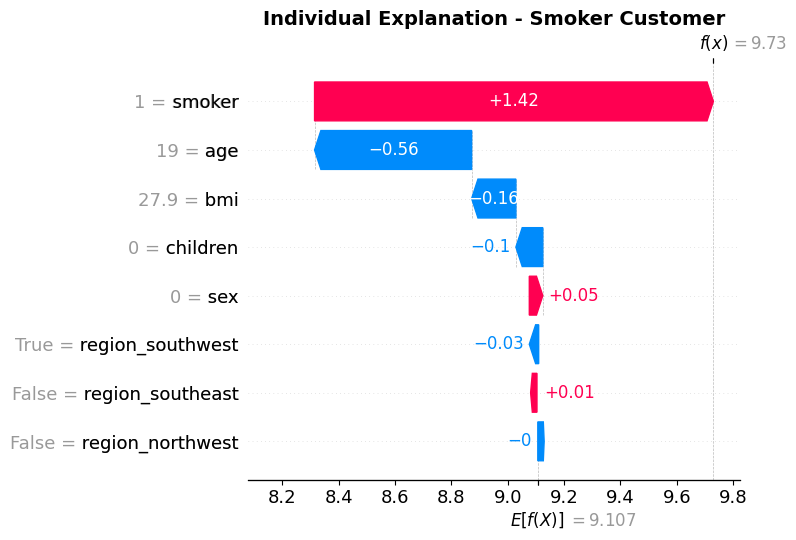


Actual charges: $16,885
Smoker: yes
Age: 19
BMI: 27.9


In [5]:

# High risk customer (smoker)
smoker_idx = df_model[df_model['smoker'] == 1].index[0]

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[smoker_idx], show=False)
plt.title('Individual Explanation - Smoker Customer', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nActual charges: ${df.iloc[smoker_idx]['charges']:,.0f}")
print(f"Smoker: {df.iloc[smoker_idx]['smoker']}")
print(f"Age: {df.iloc[smoker_idx]['age']}")
print(f"BMI: {df.iloc[smoker_idx]['bmi']}")

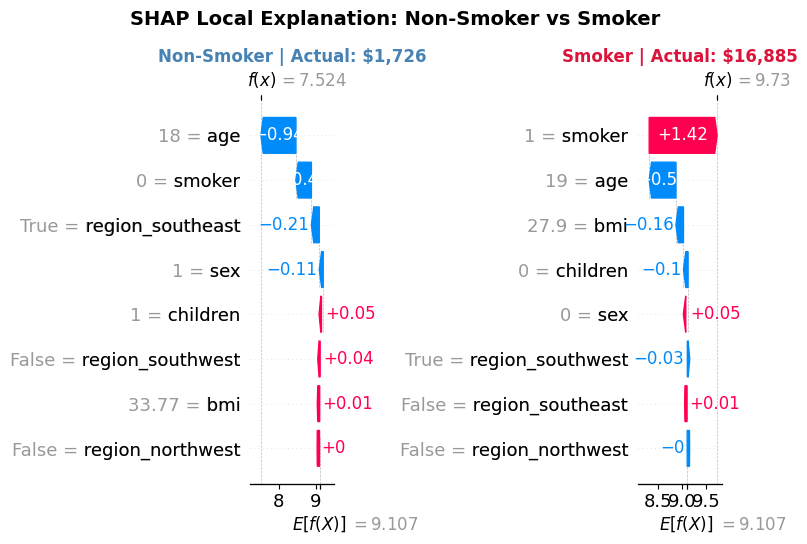

In [6]:

# Non-smoker customer
non_smoker_idx = df_model[df_model['smoker'] == 0].index[0]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.sca(axes[0])
shap.plots.waterfall(shap_values[non_smoker_idx], show=False)
axes[0].set_title(f'Non-Smoker | Actual: ${df.iloc[non_smoker_idx]["charges"]:,.0f}',
                   fontweight='bold', color='steelblue')

plt.sca(axes[1])
shap.plots.waterfall(shap_values[smoker_idx], show=False)
axes[1].set_title(f'Smoker | Actual: ${df.iloc[smoker_idx]["charges"]:,.0f}',
                   fontweight='bold', color='crimson')

plt.suptitle('SHAP Local Explanation: Non-Smoker vs Smoker', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

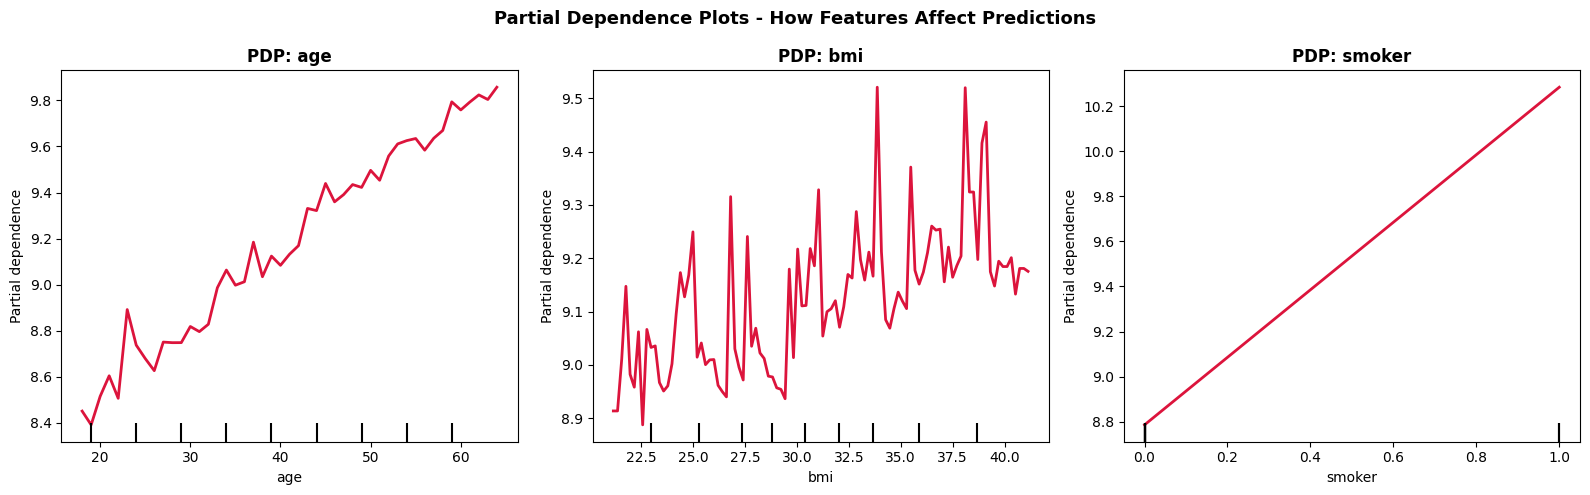

In [7]:


from sklearn.inspection import PartialDependenceDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features = ['age', 'bmi', 'smoker']

for i, feature in enumerate(features):
    feature_idx = list(X.columns).index(feature)
    PartialDependenceDisplay.from_estimator(
        model, X, [feature_idx],
        ax=axes[i],
        line_kw={'color': 'crimson', 'linewidth': 2}
    )
    axes[i].set_title(f'PDP: {feature}', fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Predicted log(Charges)')

plt.suptitle('Partial Dependence Plots - How Features Affect Predictions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

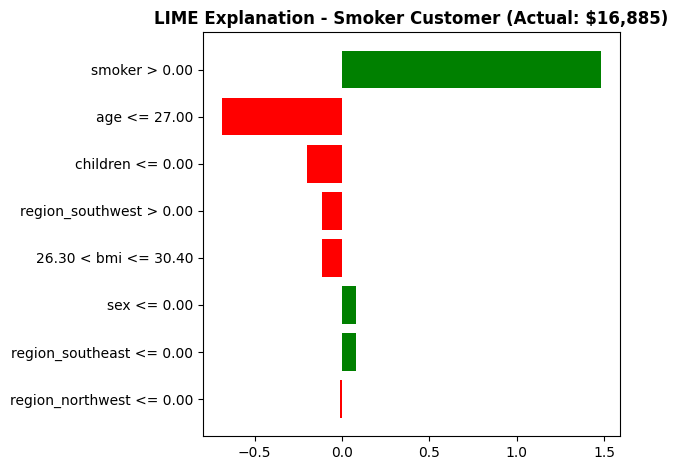


LIME Feature Contributions:
  smoker > 0.00: 1.4820
  age <= 27.00: -0.6860
  children <= 0.00: -0.2021
  region_southwest > 0.00: -0.1122
  26.30 < bmi <= 30.40: -0.1121
  sex <= 0.00: 0.0824
  region_southeast <= 0.00: 0.0799
  region_northwest <= 0.00: -0.0088


In [9]:


from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X.values,
    feature_names=X.columns.tolist(),
    mode='regression'
)

# Explain smoker customer
exp = lime_explainer.explain_instance(
    data_row=X.iloc[smoker_idx].values,
    predict_fn=model.predict,
    num_features=8
)

fig = exp.as_pyplot_figure()
plt.title(f'LIME Explanation - Smoker Customer (Actual: ${df.iloc[smoker_idx]["charges"]:,.0f})',
          fontweight='bold')
plt.tight_layout()
plt.show()

print("\nLIME Feature Contributions:")
for feat, val in exp.as_list():
    print(f"  {feat}: {val:.4f}")

=== Counterfactual Analysis ===
Customer Profile: Age 19, BMI 27.9

Scenario 1 - Current (Smoker):     $16,812
Scenario 2 - If Quit Smoking:      $2,131
Potential Savings:                 $14,681 per year
Reduction:                         87.3%


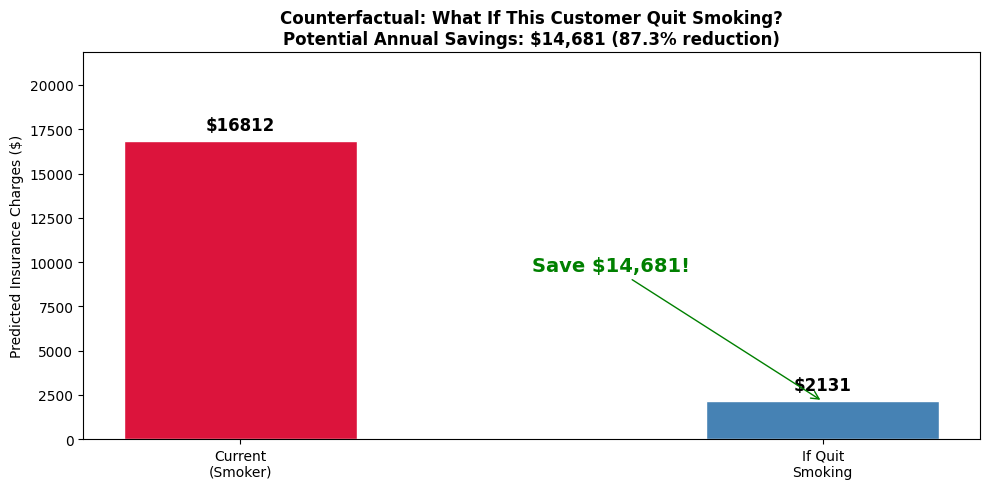

In [10]:

# Original smoker customer
original = X.iloc[smoker_idx].copy()
original_pred = np.expm1(model.predict(original.values.reshape(1, -1))[0])

# Counterfactual: same customer but non-smoker
counterfactual = original.copy()
counterfactual['smoker'] = 0
cf_pred = np.expm1(model.predict(counterfactual.values.reshape(1, -1))[0])

savings = original_pred - cf_pred

print("=== Counterfactual Analysis ===")
print(f"Customer Profile: Age {df.iloc[smoker_idx]['age']}, BMI {df.iloc[smoker_idx]['bmi']}")
print(f"\nScenario 1 - Current (Smoker):     ${original_pred:,.0f}")
print(f"Scenario 2 - If Quit Smoking:      ${cf_pred:,.0f}")
print(f"Potential Savings:                 ${savings:,.0f} per year")
print(f"Reduction:                         {savings/original_pred*100:.1f}%")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(['Current\n(Smoker)', 'If Quit\nSmoking'],
               [original_pred, cf_pred],
               color=['crimson', 'steelblue'],
               edgecolor='white', width=0.4)
ax.bar_label(bars, fmt='$%.0f', padding=5, fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Insurance Charges ($)')
ax.set_title(f'Counterfactual: What If This Customer Quit Smoking?\nPotential Annual Savings: ${savings:,.0f} ({savings/original_pred*100:.1f}% reduction)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, original_pred * 1.3)
ax.annotate(f'Save ${savings:,.0f}!', 
            xy=(1, cf_pred), xytext=(0.5, (original_pred+cf_pred)/2),
            fontsize=14, color='green', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='green'))
plt.tight_layout()
plt.show()

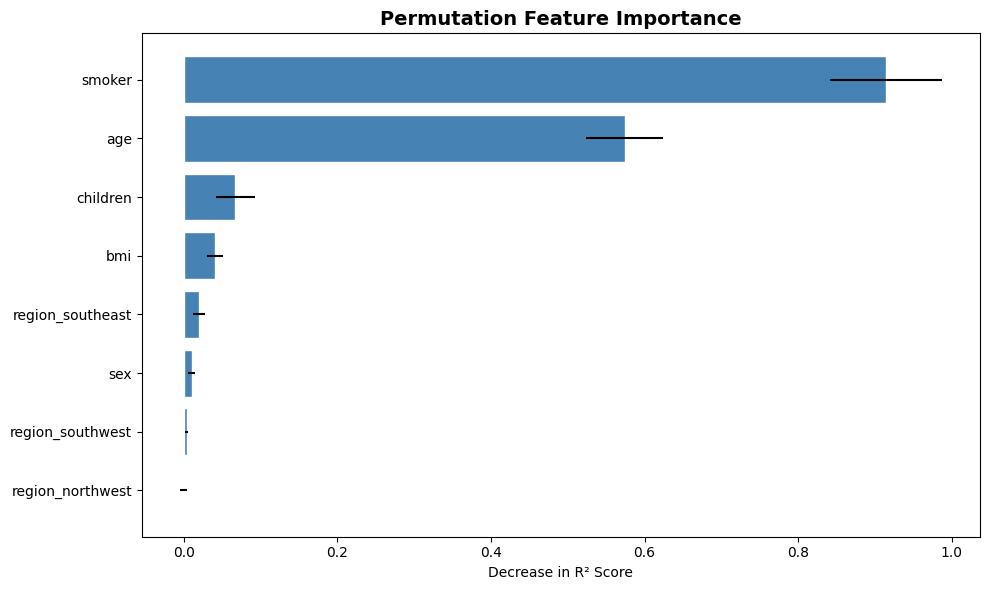

In [11]:


from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

result = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2'
)

perm_df = pd.DataFrame({
    'feature': X.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(perm_df['feature'], perm_df['importance'],
         xerr=perm_df['std'], color='steelblue', edgecolor='white')
plt.xlabel('Decrease in R² Score')
plt.title('Permutation Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()